<div align="center">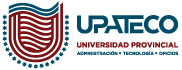</div>

# <font color="#8B5CF6">Proyecto Integrador Unidad I — Etapa 2</font>
## <font color="#de9f68">*Incorporación de nueva evidencia* — Revisión del tablero de control</font>
<font color="#adc261">**Tecnicatura universitaria en Ciencia de Datos e Inteligencia Artificial Aplicada**</font> — UPATECO  
<font color="#adc261">**Materia:**</font> Visualización y Narrativa de Datos (2026)  
<font color="#adc261">**Profesora:**</font> María Dolores Costa  

<font color="#adc261">**Integrantes:**</font>  
1. <font color="#91b9e3">Hernan Guido Gustavo Casasola (DNI 29.976.458)</font>
2. <font color="#91b9e3">*—*</font>
3. <font color="#91b9e3">*—*</font>


<font color="#adc261">**Fuente de datos:**</font> `operacion_organizacion.csv` (506 operaciones, 2023-01-02 → 2025-06-25) + <font color="#adc261">**nueva evidencia**</font> del documento institucional de AgroCampo S.A. ("Caso 8" — Informe Técnico de Producción, 05-08-2026).

> <font color="#a091e3">Notebook preparado para ejecutar en **Google Colab**. Para usarlo: abrir [colab.research.google.com](https://colab.research.google.com) → *Archivo → Subir notebook* (o arrastrar este archivo) → *Entorno de ejecución → Ejecutar todo*.</font>

### <font color="#e391e3">La nueva evidencia: Informe Técnico de Producción (AgroCampo S.A.)</font>
La Gerencia de Producción informó que entre <font color="#adc261">**septiembre y noviembre de 2024**</font> la empresa atravesó una <font color="#adc261">**etapa estacional**</font> propia del calendario productivo de los cultivos:

- <font color="#91b9e3">Finalizaron las **tareas intensivas de cosecha**.</font>
- <font color="#91b9e3">Comenzaron las actividades de **preparación y acondicionamiento de los lotes** para la próxima campaña.</font>
- <font color="#91b9e3">Parte de la **maquinaria permaneció fuera de operación** por mantenimiento preventivo programado.</font>
- <font color="#91b9e3">Se redujo temporalmente la **demanda de mano de obra operativa**.</font>
- <font color="#91b9e3">Las actividades se concentraron en **planificación, análisis de suelos y preparación de insumos**.</font>


La Gerencia aclara que estas variaciones <font color="#adc261">**forman parte del ciclo normal**</font> de la actividad agropecuaria y están contempladas en la planificación anual. 

Esta información <font color="#adc261">**no estaba disponible**</font> cuando se realizó la Etapa 1, por lo que corresponde revisar las conclusiones: parte de las variaciones observadas pueden responder a la <font color="#adc261">**estacionalidad del proceso productivo**</font> y no a una disminución del rendimiento de la organización.

<font color="#adc261">**Solicitud de la Dirección:**</font> revisar el tablero de control presentado en la Etapa 1, evaluar si los indicadores utilizados permiten interpretar correctamente una actividad estacional, proponer nuevos indicadores si hacen falta y elaborar una <font color="#adc261">**nueva recomendación**</font> para la Gerencia de Producción.

<font color="#adc261">**Entregable:**</font> presentación oral del tablero actualizado y defensa de las decisiones tomadas ante la Gerencia de Producción.


### <font color="#e391e3">Actividades de esta etapa</font>
1. <font color="#91b9e3">Identificar **qué información nueva** aporta el documento.</font>
2. <font color="#91b9e3">Determinar **cuáles conclusiones iniciales continúan siendo válidas**.</font>
3. <font color="#91b9e3">Explicar **cuáles deben modificarse y por qué**.</font>
4. <font color="#91b9e3">Analizar **si los indicadores utilizados siguen siendo suficientes**.</font>
5. <font color="#91b9e3">Proponer **nuevos KPIs** si se consideran necesarios.</font>
6. <font color="#91b9e3">**Actualizar las recomendaciones** dirigidas a la Dirección.</font>
7. <font color="#91b9e3">Reflexión final sobre **cómo la nueva evidencia modificó (o confirmó) la interpretación** del conjunto de datos.</font>

In [15]:
# Carga del dataset
# Orden de búsqueda: (1) ruta local, (2) URL cruda de GitHub,
# (3) Google Drive montado, (4) subida manual desde el navegador.

import os
import pandas as pd

RUTA = "operacion_organizacion.csv"

# URL cruda del dataset (repositorio público del proyecto):
GITHUB_RAW = "https://raw.githubusercontent.com/GuidoMaxier/visualizacion-upateco-proyecto-integrador/main/data/raw/operacion_organizacion.csv"

# Rutas locales probadas (según dónde se ejecute el notebook)
CANDIDATAS_LOCALES = [
    RUTA,
    "data/raw/" + RUTA,
    "../data/raw/" + RUTA,
    "../../data/raw/" + RUTA,  # notebooks/etapa_2/
]

df = None

# 1) Ruta local
for ruta in CANDIDATAS_LOCALES:
    if os.path.exists(ruta):
        df = pd.read_csv(ruta)
        print("[OK] Dataset cargado desde ruta local:", ruta)
        break

# 2) URL cruda de GitHub (el dataset está versionado en el repo público)
if df is None:
    try:
        df = pd.read_csv(GITHUB_RAW)
        print("[OK] Dataset cargado desde GitHub raw URL.")
    except Exception as e:
        print("No se pudo cargar desde GitHub:", e)

# 3) Google Drive montado
if df is None:
    try:
        from google.colab import drive
        drive.mount("/content/drive")
        for c in ["/content/drive/MyDrive/" + RUTA,
                  "/content/drive/MyDrive/Visualizacion/" + RUTA,
                  "/content/drive/MyDrive/Visualizacion/data/raw/" + RUTA]:
            if os.path.exists(c):
                df = pd.read_csv(c)
                print("[OK] Dataset cargado desde:", c)
                break
    except Exception as e:
        print("No se pudo acceder a Google Drive:", e)

# 4) Subida manual (último recurso)
if df is None:
    try:
        from google.colab import files
        subido = files.upload()
        df = pd.read_csv(next(iter(subido)))
        print("[OK] Dataset cargado por subida manual.")
    except Exception as e:
        print("No se pudo cargar por subida manual:", e)

assert df is not None, "No se encontró el dataset. Verificar la ruta local, GITHUB_RAW o subirlo manualmente."
print("Dimensiones:", df.shape)
df.head()


[OK] Dataset cargado desde ruta local: ../../data/raw/operacion_organizacion.csv
Dimensiones: (506, 12)


,ID,Fecha,Unidad,Region,Actividad,Horas,Recursos,Incidentes,Tiempo,Calidad,Costo,Resultado
0,499,2023-05-23,C,Norte,159.0,193.9,12,1,15.47,92.6,29890.0,225.1
1,95,2023-06-11,D,Sur,98.0,188.2,27,2,23.91,93.9,20584.0,140.2
2,151,2024-05-17,E,Norte,151.0,148.9,11,2,14.91,NaN,26795.0,232.5
3,222,2023-08-13,D,Centro,93.0,161.2,13,3,15.26,95.6,21543.0,128.5
4,424,2023-02-18,B,Norte,120.0,149.4,17,0,13.84,94.7,23026.0,192.0


In [9]:
# Dependencias y estilo
%pip install -q plotly kaleido

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio

pio.templates.default = "plotly_white"
print("Librerías listas. Versión pandas:", pd.__version__)


Note: you may need to restart the kernel to use updated packages.
Librerías listas. Versión pandas: 3.0.5


### <font color="#e391e3">Actividad 1 — ¿Qué información nueva aporta este documento?</font>
El documento <font color="#adc261">**no agrega filas ni variables**</font> al dataset, pero aporta <font color="#adc261">**contexto organizacional**</font> que la Etapa 1 no tenía (y que fue listado como "información faltante" en la Etapa 1, apartado 3 del análisis inicial):

| Información nueva | Implicancia para el análisis |
|---|---|
| Entre sep–nov 2024 hubo una etapa estacional (fin de cosecha, preparación de lotes) | Las caídas de actividad de ese trimestre pueden ser un **patrón anual**, no una anomalía |
| Parte de la maquinaria estuvo fuera de servicio por **mantenimiento preventivo** | Puede explicar menor eficiencia y mayor cantidad de incidentes en ese período |
| Se redujo temporalmente la **demanda de mano de obra operativa** | Menos recursos disponibles → mayor carga por operación |
| Las variaciones están **contempladas en la planificación anual** | La meta (`Actividad`) debería reflejar la estacionalidad |
| La Gerencia pide revisar las conclusiones | El diagnóstico "disminución del rendimiento" debe contrastarse contra el **mismo período de otros años** |

<font color="#adc261">**Qué implica para el análisis:**</font> la Etapa 1 identificó 2024-Q4 como el trimestre más conflictivo (240 incidentes, casi el doble del promedio trimestral de ≈ 120). La nueva evidencia no elimina ese dato, pero cambia su <font color="#adc261">**interpretación**</font>: parte de la caída puede ser esperable. Para distinguir *estacionalidad* de *deterioro real* hay que comparar la ventana sep–nov 2024 contra <font color="#adc261">**la misma ventana de otros años**</font> y contra el <font color="#adc261">**resto del mismo año**</font>. Eso es lo que hacemos en las Actividades 2 y 3.


In [10]:
# ── Preparación (sobre una COPIA; el original no se modifica) ─────
datos = df.copy()
datos["Fecha"] = pd.to_datetime(datos["Fecha"])
datos["Año"] = datos["Fecha"].dt.year
datos["Mes"] = datos["Fecha"].dt.month
datos["Trimestre"] = datos["Fecha"].dt.to_period("Q").astype(str)
datos["Eficiencia_Hora"] = datos["Resultado"] / datos["Horas"]
datos["Eficiencia_Costo"] = datos["Resultado"] / datos["Costo"]
datos["Cumplimiento"] = datos["Resultado"] / datos["Actividad"]

# ── Nuevas columnas para el análisis estacional ───────────────────
MESES_VENTANA = [9, 10, 11]  # septiembre, octubre y noviembre (etapa estacional)
datos["Ventana"] = datos["Mes"].isin(MESES_VENTANA)            # True si cae en la ventana
datos["Etiqueta"] = np.where(datos["Ventana"], "sep-nov", "resto del año")
datos["GrupoVentana"] = np.where(
    datos["Ventana"],
    "sep-nov " + datos["Año"].astype(str),
    "resto " + datos["Año"].astype(str),
)

print("Columnas derivadas nuevas:", ["Ventana", "Etiqueta", "GrupoVentana"])
print("Operaciones en la ventana sep-nov por año:")
print(datos[datos["Ventana"]].groupby("Año").size().to_string())
print("\nEl dataset original conserva", df.shape[0], "filas y", df.shape[1], "columnas sin cambios.")
datos.head()


Columnas derivadas nuevas: ['Ventana', 'Etiqueta', 'GrupoVentana']
Operaciones en la ventana sep-nov por año:
Año
2023    41
2024    58

El dataset original conserva 506 filas y 12 columnas sin cambios.


,ID,Fecha,Unidad,Region,Actividad,Horas,Recursos,Incidentes,Tiempo,Calidad,...,Resultado,Año,Mes,Trimestre,Eficiencia_Hora,Eficiencia_Costo,Cumplimiento,Ventana,Etiqueta,GrupoVentana
0,499,2023-05-23,C,Norte,159.0,193.9,12,1,15.47,92.6,...,225.1,2023,5,2023Q2,1.160908,0.007531,1.415723,False,resto del año,resto 2023
1,95,2023-06-11,D,Sur,98.0,188.2,27,2,23.91,93.9,...,140.2,2023,6,2023Q2,0.744952,0.006811,1.430612,False,resto del año,resto 2023
2,151,2024-05-17,E,Norte,151.0,148.9,11,2,14.91,NaN,...,232.5,2024,5,2024Q2,1.561451,0.008677,1.539735,False,resto del año,resto 2024
3,222,2023-08-13,D,Centro,93.0,161.2,13,3,15.26,95.6,...,128.5,2023,8,2023Q3,0.797146,0.005965,1.381720,False,resto del año,resto 2023
4,424,2023-02-18,B,Norte,120.0,149.4,17,0,13.84,94.7,...,192.0,2023,2,2023Q1,1.285141,0.008338,1.600000,False,resto del año,resto 2023


### <font color="#e391e3">Actividades 2 y 3 — ¿Qué conclusiones siguen siendo válidas y cuáles deben modificarse?</font>
<font color="#adc261">**Método:**</font> separar el efecto estacional del deterioro real con tres comparaciones:

1. <font color="#91b9e3">**Ventana sep–nov vs resto del año** (mismo año): si la ventana es estacional, se espera un comportamiento distinto al resto del año.</font>
2. <font color="#91b9e3">**Ventana sep–nov entre años (2023 vs 2024)**: si el patrón es *solo* estacional, la ventana debería comportarse **igual todos los años**. Si 2024 es peor que 2023 en la misma ventana, hay un agravamiento real que la estacionalidad no explica.</font>
3. <font color="#91b9e3">**Resto del año 2024 vs resto del año 2023**: si el deterioro fuera general, debería verse también fuera de la ventana.</font>
> <font color="#a091e3">**Limitación:** el dataset termina el 25/06/2025, por lo que no existe la ventana sep–nov 2025; la única comparación interanual posible de la ventana es contra **sep–nov 2023**.</font>

In [11]:
# ── Evidencia de la ventana estacional (Actividades 1–3) ──────────

def resumen_grupo(x, nombre):
    return pd.Series({
        "Grupo": nombre,
        "n": len(x),
        "Resultado total": round(x["Resultado"].sum(), 1),
        "Resultado prom.": round(x["Resultado"].mean(), 1),
        "Incidentes": int(x["Incidentes"].sum()),
        "Inc. por operación": round(x["Incidentes"].mean(), 2),
        "Eficiencia (Res/Hora)": round(x["Eficiencia_Hora"].mean(), 3),
        "Cumplimiento": round(x["Cumplimiento"].mean(), 3),
        "Calidad": round(x["Calidad"].mean(), 1),
    })

filas = []
for anio in sorted(datos["Año"].unique()):
    a = datos[datos["Año"] == anio]
    filas.append(resumen_grupo(a, f"{anio} — total"))
    v = a[a["Ventana"]]
    if len(v):
        filas.append(resumen_grupo(v, f"{anio} — sep-nov"))
    r = a[~a["Ventana"]]
    if len(r):
        filas.append(resumen_grupo(r, f"{anio} — resto"))

tabla_evidencia = pd.DataFrame(filas)
print("═" * 100)
print("TABLA 1 — Resumen por año, ventana sep-nov y resto del año")
print("═" * 100)
print(tabla_evidencia.to_string(index=False))

# Comparativa interanual de la ventana
v23 = datos[(datos["Año"] == 2023) & datos["Ventana"]]
v24 = datos[(datos["Año"] == 2024) & datos["Ventana"]]
comparativa = pd.DataFrame({
    "Indicador": ["n (operaciones)", "Resultado total", "Resultado prom.", "Incidentes",
                  "Inc. por operación", "Eficiencia (Res/Hora)", "Cumplimiento", "Calidad"],
    "sep-nov 2023": [len(v23), round(v23.Resultado.sum(), 1), round(v23.Resultado.mean(), 1),
                     int(v23.Incidentes.sum()), round(v23.Incidentes.mean(), 2),
                     round(v23.Eficiencia_Hora.mean(), 3), round(v23.Cumplimiento.mean(), 3),
                     round(v23.Calidad.mean(), 1)],
    "sep-nov 2024": [len(v24), round(v24.Resultado.sum(), 1), round(v24.Resultado.mean(), 1),
                     int(v24.Incidentes.sum()), round(v24.Incidentes.mean(), 2),
                     round(v24.Eficiencia_Hora.mean(), 3), round(v24.Cumplimiento.mean(), 3),
                     round(v24.Calidad.mean(), 1)],
})
print()
print("═" * 100)
print("TABLA 2 — Comparativa interanual de la ventana estacional (sep-nov)")
print("═" * 100)
print(comparativa.to_string(index=False))

# Detalle mensual de la ventana
detalle = datos[datos["Ventana"]].groupby(["Año", "Mes"]).agg(
    n=("ID", "count"),
    resultado=("Resultado", "sum"),
    incidentes=("Incidentes", "sum"),
    inc_por_op=("Incidentes", "mean"),
    eficiencia=("Eficiencia_Hora", "mean"),
).round(2)
print()
print("═" * 100)
print("TABLA 3 — Detalle mensual de la ventana (septiembre, octubre, noviembre)")
print("═" * 100)
print(detalle.to_string())

# Peso de la ventana dentro de cada año
print()
print("═" * 100)
print("Peso de la ventana sep-nov dentro de cada año")
print("═" * 100)
for anio in [2023, 2024]:
    a = datos[datos["Año"] == anio]
    v = a[a["Ventana"]]
    print(f"{anio}: ventana = {len(v)}/{len(a)} operaciones ({len(v) / len(a) * 100:.0f}%) | "
          f"incidentes {v.Incidentes.sum()}/{a.Incidentes.sum()} ({v.Incidentes.sum() / a.Incidentes.sum() * 100:.0f}%) | "
          f"resultado {v.Resultado.sum() / a.Resultado.sum() * 100:.0f}% del total anual")

# Incidentes por operación por mes en 2024 (¿el pico se contiene en sep-nov?)
incop_2024 = datos[datos["Año"] == 2024].groupby("Mes")["Incidentes"].mean().round(2)
print()
print("═" * 100)
print("2024 — incidentes por operación por mes (¿el pico se contiene en sep–nov?)")
print("═" * 100)
print(incop_2024.to_string())

# Ventana por Unidad y Región
print()
print("═" * 100)
print("Ventana sep-nov por Unidad (2023 vs 2024)")
print("═" * 100)
print(datos[datos["Ventana"]].groupby(["Año", "Unidad"]).agg(
    n=("ID", "count"), incidentes=("Incidentes", "sum"), inc_por_op=("Incidentes", "mean")
).round(2).to_string())
print()
print("Ventana sep-nov por Región (2023 vs 2024)")
print(datos[datos["Ventana"]].groupby(["Año", "Region"]).agg(
    n=("ID", "count"), incidentes=("Incidentes", "sum"), inc_por_op=("Incidentes", "mean")
).round(2).to_string())

# Estabilidad de las relaciones dentro de la ventana
c_ventana = datos[datos["Ventana"]][["Actividad", "Resultado", "Incidentes", "Calidad"]].corr()
print()
print("═" * 100)
print("Correlaciones dentro de la ventana estacional (todos los años)")
print("═" * 100)
print("r(Actividad, Resultado):", round(c_ventana.loc["Actividad", "Resultado"], 2))
print("r(Incidentes, Resultado):", round(c_ventana.loc["Incidentes", "Resultado"], 2))

# ── Gráficos ───────────────────────────────────────────────────────
# 1) Incidentes por operación: ventana vs resto del año
inc_por_grupo = datos.groupby(["Año", "Ventana"])["Incidentes"].mean().reset_index()
inc_por_grupo["Etiqueta"] = np.where(inc_por_grupo["Ventana"], "sep-nov", "resto del año")

fig1 = px.bar(
    inc_por_grupo, x="Año", y="Incidentes", color="Etiqueta", barmode="group",
    labels={"Año": "Año", "Incidentes": "Incidentes por operación", "Etiqueta": "Período"},
    title="Incidentes por operación: ventana estacional (sep-nov) vs resto del año",
    color_discrete_map={"sep-nov": "tomato", "resto del año": "steelblue"},
    text=inc_por_grupo["Incidentes"].round(2),
)
fig1.update_traces(textposition="outside")
fig1.update_layout(height=420)
fig1.show()

# 2) Resultado e incidentes mensuales con la ventana estacional sombreada
mensual = datos.groupby(datos["Fecha"].dt.to_period("M")).agg(
    resultado=("Resultado", "sum"), incidentes=("Incidentes", "sum")
)
mensual.index = mensual.index.astype(str)

fig2 = make_subplots(rows=2, cols=1, shared_xaxes=True,
                     subplot_titles=("Resultado mensual (suma) — ventana sep-nov sombreada",
                                     "Incidentes mensuales (suma) — ventana sep-nov sombreada"),
                     vertical_spacing=0.10)
fig2.add_trace(go.Bar(x=mensual.index, y=mensual["resultado"], name="Resultado",
                      marker_color="steelblue"), row=1, col=1)
fig2.add_trace(go.Bar(x=mensual.index, y=mensual["incidentes"], name="Incidentes",
                      marker_color="tomato"), row=2, col=1)
for anio in [2023, 2024]:
    fig2.add_vrect(x0=f"{anio}-09", x1=f"{anio}-11", fillcolor="orange", opacity=0.15,
                   line_width=0, annotation_text=f"ventana {anio}",
                   annotation_position="top left", row="all")
fig2.update_layout(height=660, title="Evolución mensual 2023–2025 con la etapa estacional")
fig2.show()


════════════════════════════════════════════════════════════════════════════════════════════════════
TABLA 1 — Resumen por año, ventana sep-nov y resto del año
════════════════════════════════════════════════════════════════════════════════════════════════════
         Grupo   n  Resultado total  Resultado prom.  Incidentes  Inc. por operación  Eficiencia (Res/Hora)  Cumplimiento  Calidad
  2023 — total 194          32949.8            169.8         403                2.08                  1.033         1.395     91.2
2023 — sep-nov  41           7387.4            180.2          82                2.00                  1.125         1.403     90.9
  2023 — resto 153          25562.4            167.1         321                2.10                  1.008         1.393     91.3
  2024 — total 209          33429.9            160.0         592                2.83                  1.001         1.373     88.3
2024 — sep-nov  58           7118.6            122.7         296                5.10

### <font color="#e391e3">Actividad 2 — ¿Qué conclusiones de la Etapa 1 continúan siendo válidas?</font>
Con la evidencia de las tablas anteriores, las conclusiones <font color="#adc261">**estructurales**</font> de la Etapa 1 se mantienen:

1. <font color="#91b9e3">**`Actividad` funciona como meta** (r = 0,97 con `Resultado`; dentro de la ventana estacional: r = 0,98). El cumplimiento promedio real es **1,386** (≈ 39 % por encima de la meta) — se corrige el valor "1,05" citado en la Etapa 1, que no coincidía con el cálculo ejecutado.</font>
2. <font color="#91b9e3">**La Región Sur y la Unidad C concentran los incidentes** a nivel global (457 y 284) y, dentro de la ventana 2024, **todas las Unidades y Regiones** empeoran (inc/op entre 4,4 y 6,2 por Unidad; entre 4,9 y 5,2 por Región): el fenómeno es sistémico, no de una unidad puntual.</font>
3. <font color="#91b9e3">**La Unidad D mantiene la menor eficiencia** (0,997 global; 0,687 en la ventana 2024) y la **Unidad B la mayor** (1,059 global; 0,913 en la ventana, la caída relativa más leve).</font>
4. <font color="#91b9e3">**Calidad y costo se comportan de forma inversa** (r = −0,22) y, en la ventana 2024, el costo promedio sube (27 743 vs 23 637 del resto de 2024) mientras calidad y eficiencia caen.</font>
5. <font color="#91b9e3">**La calidad de los datos es aceptable** (22 filas con faltantes, 4,3 %; 6 duplicadas): no se modificó el dataset original.</font>
> <font color="#a091e3">**Nota de trazabilidad:** los totales por Unidad/Región (Sur 457, Unidad C 284), las eficiencias por Unidad (0,997 y 1,059 globales; 0,687 y 0,913 en la ventana) y la calidad de datos (22 filas con faltantes, 6 duplicadas) se calcularon en el notebook de la **Etapa 1** (celdas de calidad de datos, comparativos y KPIs) y se reutilizan aquí como referencia estructural.</font>
### <font color="#e391e3">Actividad 3 — ¿Qué conclusiones deben modificarse y por qué?</font>
La conclusión que <font color="#adc261">**cambia**</font> es la interpretación del deterioro de <font color="#adc261">**2024-Q4**</font>:

| Conclusión Etapa 1 | Revisión con la nueva evidencia | Por qué |
|---|---|---|
| "2024-Q4 fue un trimestre anómalo (240 incidentes, ≈ 2× el promedio trimestral): principal señal de alarma" | Se **matiza**: el contexto es una **etapa estacional normal** (fin de cosecha, preparación de lotes, mantenimiento de maquinaria, menor dotación) contemplada en la planificación anual | La ventana sep–nov existe todos los años y en 2023 fue normal (2,00 inc/op vs 2,08 del año) |
| "El bajo rendimiento del período sugiere una caída general de la organización" | Se **descarta**: fuera de la ventana, 2024 fue **mejor que 2023** (inc/op 1,96 vs 2,10; resultado promedio 174,2 vs 167,1) | El deterioro de 2024 se concentra exclusivamente en sep–nov |
| "Los incidentes son el principal riesgo operativo" | **Se mantiene, reencuadrado**: el riesgo es real y accionable, y se concentra en la ventana estacional | La misma ventana en 2023 no mostró el pico: inc/op 5,10 vs 2,00 (+155 %); eficiencia −32 %; calidad 82,3 vs 90,9 |

<font color="#adc261">**Síntesis:**</font> la nueva evidencia <font color="#adc261">**confirma**</font> que existe estacionalidad (el contexto se repite cada año), pero la <font color="#adc261">**comparación interanual de la misma ventana**</font> demuestra que sep–nov 2024 fue <font color="#adc261">**significativamente peor que sep–nov 2023**</font>. La estacionalidad explica *el contexto* del período (menos cosecha, más mantenimiento), <font color="#adc261">**no**</font> el agravamiento dentro de la ventana. Ese agravamiento (más incidentes por operación, menor eficiencia y calidad, mayor costo) sigue siendo un problema real de gestión.

### <font color="#e391e3">Actividad 4 — ¿Los indicadores de la Etapa 1 siguen siendo suficientes?</font>
Los KPIs de la Etapa 1 (resultado promedio, cumplimiento, eficiencias, costo promedio, tasa de incidentes, calidad, tiempo) son <font color="#adc261">**promedios y agregados globales**</font>: correctos para describir el nivel general del período, pero <font color="#adc261">**no distinguen estacionalidad de tendencia**</font>. Con los datos desagregados por ventana y por año se puede verificar si un indicador global "enmascara" el comportamiento estacional.


In [12]:
# ── Actividad 4: los KPIs de la Etapa 1, ¿globales o por ventana? ─

# Mismos KPIs de la Etapa 1, calculados en cuatro contextos
contextos = {
    "Global (2023–2025)": datos,
    "Ventana sep-nov 2023": datos[(datos["Año"] == 2023) & datos["Ventana"]],
    "Ventana sep-nov 2024": datos[(datos["Año"] == 2024) & datos["Ventana"]],
    "Resto de 2024": datos[(datos["Año"] == 2024) & ~datos["Ventana"]],
}

def kpis_contexto(x):
    return {
        "n": len(x),
        "Resultado prom.": round(x["Resultado"].mean(), 1),
        "Cumplimiento": round(x["Cumplimiento"].mean(), 3),
        "Eficiencia (Res/Hora)": round(x["Eficiencia_Hora"].mean(), 3),
        "Inc. por operación": round(x["Incidentes"].mean(), 2),
        "Calidad": round(x["Calidad"].mean(), 1),
        "Costo prom.": round(x["Costo"].mean(), 0),
    }

tabla_contextos = pd.DataFrame({k: kpis_contexto(v) for k, v in contextos.items()}).T
print("═" * 100)
print("Los KPIs de la Etapa 1 calculados por contexto: ¿qué oculta el valor global?")
print("═" * 100)
print(tabla_contextos.to_string())
print()
print("Lectura: el KPI global es un promedio que ENMASCARA el comportamiento estacional.")
print("Por ejemplo, 'Inc. por operación' global = 2,37 no refleja ni los 5,10 de la")
print("ventana sep-nov 2024 ni los 1,96 del resto de 2024.")


════════════════════════════════════════════════════════════════════════════════════════════════════
Los KPIs de la Etapa 1 calculados por contexto: ¿qué oculta el valor global?
════════════════════════════════════════════════════════════════════════════════════════════════════
                          n  Resultado prom.  Cumplimiento  Eficiencia (Res/Hora)  Inc. por operación  Calidad  Costo prom.
Global (2023–2025)    506.0            166.0         1.386                  1.025                2.37     89.9      24114.0
Ventana sep-nov 2023   41.0            180.2         1.403                  1.125                2.00     90.9      24339.0
Ventana sep-nov 2024   58.0            122.7         1.283                  0.763                5.10     82.3      27743.0
Resto de 2024         151.0            174.2         1.407                  1.091                1.96     90.6      23637.0

Lectura: el KPI global es un promedio que ENMASCARA el comportamiento estacional.
Por ejemplo, 'Inc.

### <font color="#e391e3">Actividad 4 — Conclusión: los indicadores globales NO son suficientes para una actividad estacional</font>
La tabla anterior lo demuestra: el KPI global (2,37 incidentes por operación) <font color="#adc261">**enmascara**</font> una ventana de 5,10 y un resto de año de 1,96. Los indicadores de la Etapa 1 siguen siendo <font color="#adc261">**válidos para el monitoreo general**</font>, pero resultan <font color="#adc261">**insuficientes**</font> para interpretar correctamente una actividad estacional porque:

1. <font color="#91b9e3">Son **promedios anuales**: promedian períodos que por diseño se comportan distinto (cosecha vs preparación de lotes).</font>
2. <font color="#91b9e3">**No tienen baseline interanual**: sin comparar contra la misma ventana del año anterior no se puede separar estacionalidad de deterioro real.</font>
3. <font color="#91b9e3">Las **series temporales** muestran el pico (incidentes 2024-Q4 = 240) pero no permiten por sí solas decidir si es esperable o no.</font>
Por eso se proponen los nuevos KPIs de la Actividad 5, todos calculables con los datos disponibles.


### <font color="#e391e3">Actividad 5 — Nuevos KPIs propuestos</font>
Para una actividad estacional se necesitan indicadores <font color="#adc261">**por ventana**</font> y con <font color="#adc261">**baseline interanual**</font> (comparación contra la misma ventana del año anterior):

| Nuevo KPI | Fórmula | sep–nov 2023 | sep–nov 2024 | Qué mide |
|---|---|---|---|---|
| **Tasa de incidentes por operación en la ventana** | `Incidentes` / operaciones en sep–nov | 2,00 | **5,10** | Intensidad de incidentes del período estacional |
| **Índice de estacionalidad de incidentes** | inc/op ventana ÷ inc/op anual | 0,96 | **1,80** | Cuánto concentra la ventana (> 1 = por encima del año) |
| **Variación interanual de la ventana** | Δ % vs misma ventana del año anterior | — | inc/op **+155 %**; eficiencia **−32 %** | Deterioro real vs año previo en la misma ventana |
| **Cumplimiento en la ventana** | `Resultado/Actividad` en sep–nov | 1,403 | 1,283 | Si la planificación (meta) contempló la estacionalidad |
| **Eficiencia en la ventana** | `Resultado/Horas` en sep–nov | 1,125 | **0,763** | Rendimiento por hora del período estacional |
| **Peso de la ventana** | % de incidentes anuales en sep–nov | 20 % | **50 %** | Concentración del riesgo en el período |
| **Resultado por operación en la ventana** | Media de `Resultado` en sep–nov | 180,2 | **122,7** | Nivel de producción unitario del período |


In [13]:
# ── Actividad 5: cálculo de los nuevos KPIs estacionales ──────────
v23 = datos[(datos["Año"] == 2023) & datos["Ventana"]]
v24 = datos[(datos["Año"] == 2024) & datos["Ventana"]]
a23 = datos[datos["Año"] == 2023]
a24 = datos[datos["Año"] == 2024]

incop = lambda x: x["Incidentes"].mean()

nuevos_kpis = pd.DataFrame({
    "KPI": [
        "Tasa de incidentes por operación en la ventana",
        "Índice de estacionalidad de incidentes",
        "Variación interanual de la ventana (inc. por op.)",
        "Variación interanual de la ventana (eficiencia)",
        "Cumplimiento en la ventana",
        "Eficiencia en la ventana",
        "Peso de la ventana en los incidentes anuales",
        "Resultado por operación en la ventana",
    ],
    "Fórmula / definición": [
        "Media de Incidentes en sep-nov",
        "inc/op ventana ÷ inc/op del año",
        "(inc/op 2024 − inc/op 2023) / inc/op 2023",
        "(eficiencia 2024 − eficiencia 2023) / eficiencia 2023",
        "Media de Resultado/Actividad en sep-nov",
        "Media de Resultado/Horas en sep-nov",
        "Incidentes sep-nov ÷ incidentes del año",
        "Media de Resultado en sep-nov",
    ],
    "sep-nov 2023": [
        round(incop(v23), 2),
        round(incop(v23) / incop(a23), 2),
        "—", "—",
        round(v23.Cumplimiento.mean(), 3),
        round(v23.Eficiencia_Hora.mean(), 3),
        f"{v23.Incidentes.sum() / a23.Incidentes.sum() * 100:.0f} %",
        round(v23.Resultado.mean(), 1),
    ],
    "sep-nov 2024": [
        round(incop(v24), 2),
        round(incop(v24) / incop(a24), 2),
        f"{(incop(v24) / incop(v23) - 1) * 100:+.0f} %",
        f"{(v24.Eficiencia_Hora.mean() / v23.Eficiencia_Hora.mean() - 1) * 100:+.0f} %",
        round(v24.Cumplimiento.mean(), 3),
        round(v24.Eficiencia_Hora.mean(), 3),
        f"{v24.Incidentes.sum() / a24.Incidentes.sum() * 100:.0f} %",
        round(v24.Resultado.mean(), 1),
    ],
})
print("═" * 100)
print("NUEVOS KPIs — baseline interanual de la ventana estacional")
print("═" * 100)
print(nuevos_kpis.to_string(index=False))

# Comparación visual de los KPIs de la ventana (2023 vs 2024), por escala
def valor_kpi(k, anio):
    v = v23 if anio == 2023 else v24
    return {
        "Inc. por operación": incop(v),
        "Eficiencia (Res/Hora)": v.Eficiencia_Hora.mean(),
        "Cumplimiento": v.Cumplimiento.mean(),
        "Resultado prom.": v.Resultado.mean(),
        "Calidad": v.Calidad.mean(),
    }[k]

fig3 = make_subplots(rows=1, cols=3,
                     subplot_titles=("Inc. por operación", "Eficiencia y cumplimiento",
                                     "Resultado y calidad"),
                     horizontal_spacing=0.12)
for kpis, col in [(["Inc. por operación"], 1),
                  (["Eficiencia (Res/Hora)", "Cumplimiento"], 2),
                  (["Resultado prom.", "Calidad"], 3)]:
    for anio, nombre, color in [(2023, "sep-nov 2023", "steelblue"),
                                (2024, "sep-nov 2024", "tomato")]:
        vals = [valor_kpi(k, anio) for k in kpis]
        fig3.add_trace(go.Bar(x=kpis, y=vals, name=nombre, marker_color=color,
                              text=[round(v, 2) for v in vals], textposition="outside"),
                       row=1, col=col)
fig3.update_layout(height=430, barmode="group",
                   title="KPIs de la ventana estacional: sep-nov 2023 vs sep-nov 2024")
fig3.show()


════════════════════════════════════════════════════════════════════════════════════════════════════
NUEVOS KPIs — baseline interanual de la ventana estacional
════════════════════════════════════════════════════════════════════════════════════════════════════
                                              KPI                                  Fórmula / definición sep-nov 2023 sep-nov 2024
   Tasa de incidentes por operación en la ventana                        Media de Incidentes en sep-nov          2.0          5.1
           Índice de estacionalidad de incidentes                       inc/op ventana ÷ inc/op del año         0.96          1.8
Variación interanual de la ventana (inc. por op.)             (inc/op 2024 − inc/op 2023) / inc/op 2023            —       +155 %
  Variación interanual de la ventana (eficiencia) (eficiencia 2024 − eficiencia 2023) / eficiencia 2023            —        -32 %
                       Cumplimiento en la ventana               Media de Resultado/Activi

### <font color="#e391e3">Actividad 6 — Recomendaciones actualizadas para la Dirección</font>
A partir de la nueva evidencia y de los indicadores revisados:

1. <font color="#91b9e3">**[Se ajusta] Gestionar la ventana estacional como período crítico recurrente.** La prioridad sigue siendo reducir incidentes, pero el foco pasa de "2024-Q4 anómalo" a **sep–nov como ventana de riesgo estructural**: en 2024 concentró el 50 % de los incidentes anuales con solo el 28 % de las operaciones (5,10 inc/op vs 2,00 en la misma ventana de 2023). → *Acción:* planificar la ventana (mantenimiento preventivo escalonado en lugar de simultáneo, dotación y procedimientos específicos para la preparación de lotes) y monitorearla con los nuevos KPIs.</font>
2. <font color="#91b9e3">**[Nueva] Incorporar la estacionalidad a la planificación (meta `Actividad`).** El cumplimiento promedio es **1,386** (≈ 39 % por encima de la meta) y aun en la peor ventana se cumple (1,283), lo que indica que la meta no refleja el ciclo productivo. → *Acción:* calibrar `Actividad` por período (campaña vs entre-campaña) para que el desvío sea una señal de gestión real y no un artefacto estacional.</font>
3. <font color="#91b9e3">**[Se mantiene] Revisar la Unidad D.** Sigue siendo la de menor eficiencia (0,997 global; 0,687 en la ventana 2024, la peor de todas las unidades). → *Acción:* auditar su proceso dentro de la ventana.</font>
4. <font color="#91b9e3">**[Se mantiene] Escalar las prácticas de la Unidad B.** Mayor eficiencia global (1,059) y la caída relativa más leve dentro de la ventana 2024 (0,913). → *Acción:* documentar y replicar sus procesos.</font>
5. <font color="#91b9e3">**[Se ajusta] Auditar el costo en la ventana.** En sep–nov 2024 el costo promedio subió a 27 743 (+14 % vs el resto de 2024: 23 637) mientras calidad (82,3) y eficiencia (0,763) cayeron: se gasta más justo cuando se produce peor. → *Acción:* revisar las partidas de mantenimiento y preparación de lotes.</font>
6. <font color="#91b9e3">**[Nueva] Monitoreo con baseline interanual.** Incorporar al tablero los KPIs por ventana con comparación contra la misma ventana del año anterior, para distinguir estacionalidad de tendencia en cada ciclo.</font>

In [14]:
# ══ TABLERO DE CONTROL ACTUALIZADO (con panel estacional) ══════════

mensual = datos.groupby(datos["Fecha"].dt.to_period("M")).agg(
    resultado=("Resultado", "sum"), incidentes=("Incidentes", "sum")
)
mensual.index = mensual.index.astype(str)

# Agrupaciones para el tablero
inc_vs_resto = datos.groupby(["Año", "Ventana"])["Incidentes"].mean().reset_index()
inc_vs_resto["Etiqueta"] = np.where(inc_vs_resto["Ventana"], "sep-nov", "resto")

peso_ventana = []
for anio in [2023, 2024]:
    a = datos[datos["Año"] == anio]
    v = a[a["Ventana"]]
    peso_ventana.append({"Año": anio, "% incidentes": v.Incidentes.sum() / a.Incidentes.sum() * 100})
peso_ventana = pd.DataFrame(peso_ventana)

calidad_vr = datos.groupby(["Año", "Ventana"])["Calidad"].mean().reset_index().rename(
    columns={"Calidad": "calidad"})
calidad_vr["Etiqueta"] = np.where(calidad_vr["Ventana"], "sep-nov", "resto")

kpis_ventana = pd.DataFrame({
    "KPI": ["Inc. por operación", "Eficiencia", "Cumplimiento"],
    "sep-nov 2023": [incop(v23), v23.Eficiencia_Hora.mean(), v23.Cumplimiento.mean()],
    "sep-nov 2024": [incop(v24), v24.Eficiencia_Hora.mean(), v24.Cumplimiento.mean()],
}).melt(id_vars="KPI", var_name="Período", value_name="Valor")

tab = make_subplots(
    rows=3, cols=2,
    subplot_titles=("Resultado mensual (ventana sep-nov sombreada)",
                    "Incidentes mensuales (ventana sep-nov sombreada)",
                    "Incidentes por operación: ventana vs resto",
                    "KPIs de la ventana: sep-nov 2023 vs 2024",
                    "Peso de la ventana en los incidentes anuales",
                    "Calidad: ventana vs resto del año"),
    vertical_spacing=0.12, horizontal_spacing=0.13,
)

# (1,1) Resultado mensual con la ventana sombreada
tab.add_trace(go.Bar(x=mensual.index, y=mensual["resultado"], marker_color="steelblue",
                     name="Resultado"), 1, 1)
# (2,1) Incidentes mensuales con la ventana sombreada
tab.add_trace(go.Bar(x=mensual.index, y=mensual["incidentes"], marker_color="tomato",
                     name="Incidentes"), 2, 1)
# (3,1) Incidentes por operación: ventana vs resto del año
for etiqueta, color in [("sep-nov", "tomato"), ("resto", "steelblue")]:
    sub = inc_vs_resto[inc_vs_resto["Etiqueta"] == etiqueta]
    tab.add_trace(go.Bar(x=sub["Año"], y=sub["Incidentes"], name=etiqueta, marker_color=color,
                         text=sub["Incidentes"].round(2), textposition="outside"), 3, 1)
# (1,2) KPIs de la ventana: 2023 vs 2024
for periodo, color in [("sep-nov 2023", "steelblue"), ("sep-nov 2024", "tomato")]:
    sub = kpis_ventana[kpis_ventana["Período"] == periodo]
    tab.add_trace(go.Bar(x=sub["KPI"], y=sub["Valor"], name=periodo, marker_color=color,
                         text=sub["Valor"].round(2), textposition="outside"), 1, 2)
# (2,2) Peso de la ventana en los incidentes anuales
tab.add_trace(go.Bar(x=peso_ventana["Año"], y=peso_ventana["% incidentes"],
                     marker_color="orange", name="Peso ventana",
                     text=peso_ventana["% incidentes"].round(0), textposition="outside"), 2, 2)
# (3,2) Calidad: ventana vs resto del año
for etiqueta, color in [("sep-nov", "tomato"), ("resto", "steelblue")]:
    sub = calidad_vr[calidad_vr["Etiqueta"] == etiqueta]
    tab.add_trace(go.Bar(x=sub["Año"], y=sub["calidad"], name=etiqueta, marker_color=color,
                         text=sub["calidad"].round(1), textposition="outside"), 3, 2)

# Sombreado de la ventana estacional en las series mensuales
for anio in [2023, 2024]:
    tab.add_vrect(x0=f"{anio}-09", x1=f"{anio}-11", row=1, col=1,
                  fillcolor="orange", opacity=0.15, line_width=0)
    tab.add_vrect(x0=f"{anio}-09", x1=f"{anio}-11", row=2, col=1,
                  fillcolor="orange", opacity=0.15, line_width=0)

tab.update_layout(
    height=1020, title="TABLERO DE CONTROL ACTUALIZADO — Incorporación de la estacionalidad (sep–nov)",
    title_font_size=18,
    legend=dict(orientation="h", yanchor="bottom", y=1.02, x=0.25),
)
tab.show()


### <font color="#e391e3">Actividad 7 — Reflexión final: cómo la nueva evidencia modificó (o confirmó) la interpretación</font>
La nueva evidencia <font color="#adc261">**no invalidó el análisis de la Etapa 1, pero lo recontextualizó**</font> y lo obligó a ser más preciso:

- <font color="#91b9e3">**Confirmó** las relaciones estructurales: `Actividad` sigue actuando como meta (r = 0,97 global; 0,98 dentro de la ventana), la Región Sur y la Unidad C concentran incidentes, la Unidad D es la menos eficiente y la relación costo–calidad sigue siendo inversa.</font>
- <font color="#91b9e3">**Modificó** la lectura del deterioro de 2024: lo que parecía una caída generalizada (2024-Q4 con 240 incidentes) es, en parte, el **ciclo estacional esperable** (fin de cosecha, mantenimiento, menor dotación). Fuera de la ventana, 2024 fue mejor que 2023.</font>
- <font color="#91b9e3">**No lo explicó todo:** la comparación contra la misma ventana de 2023 (5,10 vs 2,00 inc/op; eficiencia 0,763 vs 1,125; calidad 82,3 vs 90,9) muestra un **agravamiento específico** de sep–nov 2024 que la estacionalidad por sí sola no justifica.</font>
- <font color="#91b9e3">**Corrigió** un dato de la Etapa 1: el cumplimiento promedio es **1,386**, no 1,05.</font>
<font color="#adc261">**Lección metodológica:**</font> en una actividad con estacionalidad, los indicadores globales deben complementarse con <font color="#adc261">**ventanas temporales**</font> y <font color="#adc261">**comparaciones contra el mismo período del año anterior**</font>; de lo contrario, el tablero puede leer como "deterioro" lo que es ciclo — o, peor, pasar por alto un deterioro real escondido dentro del ciclo.

### <font color="#e391e3">Cierre</font>
Entrega de la <font color="#adc261">**Etapa 2**</font>: presentación oral del tablero de control actualizado y defensa de las decisiones ante la Gerencia de Producción de AgroCampo S.A. Este notebook documenta el razonamiento completo: qué aportó la nueva evidencia, qué conclusiones se mantienen, cuáles se modifican y por qué, la suficiencia de los indicadores, los nuevos KPIs y las recomendaciones actualizadas.
